# Minimum Snap 复现

### **1. 理论背景与变量定义 (Background)**

- 平坦输出 (Flat Outputs)： 优化基于四旋翼无人机的平坦输出空间，即世界坐标系下的位置 $[x, y, z]$ 和偏航角 $\psi$。
- 分段多项式 (Piecewise Polynomial)： 轨迹由穿过预设关键帧 (Keyframes) 的分段多项式构成。该实现中每段轨迹均使用7阶多项式。

  使用了 7 阶多项式：$$w_s(\tau)=a_{s,0}+a_{s,1}\tau+a_{s,2}\tau^2+\cdots+a_{s,7}\tau^7$$

  其中：
  - w 可以是 $x$, $y$, $z$, $\psi$
  - $s$ 是分段的索引
  - $\tau$ 是分段内的局部时间
  - $a_{s,i}$ 是多项式系数
  - 优化器负责选择这些多项式系数。
- 决策变量 ($c$)： 优化器的决策变量不是直接的轨迹点，而是所有多项式段的系数。

### **2. 目标函数构建 (Cost Matrix Construction)**

优化的目标是让无人机的飞行尽可能平滑，使得高阶控制输入的代价最小。在OSQP的标准型 $\min_c \frac{1}{2}c^T P c + q^T c$ 中：
- 位置代价 ($x, y, z$)： 惩罚第4阶导数，即最小化Snap的平方积分： $$
\int
\left\|
\frac{d^4 r_T(t)}{dt^4}
\right\|^2
dt
$$
- 偏航代价 ($\psi$)： 惩罚第2阶导数，即最小化角加速度的平方积分： $$
\int
\left(
\frac{d^2 \psi_T(t)}{dt^2}
\right)^2
dt
$$
- 矩阵组装： 上述多项式导数的平方积分可以通过解析方法转换为二次型 $c^T Q c$。为了匹配OSQP格式，设目标矩阵 $P = 2Q$，线性项 $q = 0$。同时在 $P$ 的对角线上添加了微小的正则化项（$10^{-9}$）以避免矩阵奇异，保证求解的数值稳定性。

#### **为什么要最小化这两个函数？**

这直接关系到四旋翼动力学中推力 $f$ 和力矩 $\boldsymbol{\tau}$ 的合成。通过微分平坦特性，轨迹的各阶导数与无人机的实际状态有着严格的物理映射：
- 一阶导 $\dot{\mathbf{r}}$：对应线速度 $v$。
- 二阶导 $\ddot{\mathbf{r}}$ (加速度)：决定了机体坐标系 $Z_b$ 轴的朝向，以及总推力 $f$ 的大小（对应平移方程中的 $m\dot{v}$ 项）。
- 三阶导 $\mathbf{r}^{(3)}$ (Jerk)：对应推力的变化率，并与机体的角速度 $\omega$ 发生耦合。
- 四阶导 $\mathbf{r}^{(4)}$ (Snap)：直接关系到机体的角加速度 $\dot{\omega}$（对应旋转方程中的 $M\dot{\omega}$ 项），进而在物理上正比于无人机四个电机需要实际输出的控制力矩 $\boldsymbol{\tau}$。

因此，最小化 $\mathbf{r}$ 的四阶导数，物理本质上是为了使控制力矩 $\boldsymbol{\tau}$ 的变化最平滑，避免电机输出剧烈跳变。

同理，这也是为什么在 OSQP 优化目标中，偏航角 $\psi$ 通常只需要惩罚到二阶导数 $\int (\ddot{\psi})^2 dt$，因为偏航角的二阶导（偏航角加速度）已经直接对应了偏航力矩。

#### **OSQP 求解 (Solving QP)**
- 参数配置： 收集所有的系数构造出稀疏矩阵 $P, q, A, l, u$，将这些参数传递给 osqp.OSQP() 接口。
- 计算最优解： 运行求解器，求得最优结果向量 $c^*$。这个向量包含了最终定义整条分段平滑轨迹的所有多项式系数。

In [11]:
# - OSQP Python interface: problem setup uses P, q, A, l, u.
# - Standard OSQP form: minimize 1/2 c^T P c + q^T c subject to l <= A c <= u.

import numpy as np
import scipy.sparse as sp
import osqp
import matplotlib.pyplot as plt

print("OSQP version:", osqp.__version__)

OSQP version: 1.0.5


#### **P的求法：**

前面我们已经把单独一段的，对于单一参数（例如$x$)的轨迹函数表示为了关于时间的七阶多项式，即

$$w(t) = c_0 + c_1t + c_2t^2 + \dots + c_nt^n = \sum_{i=0}^{n} c_i t^i$$

我们要求它的第 $k$ 阶导数。（注：对于 $x$ , $y$ , $z$，$k=4$；对于 $\psi$，$k=2$）对 $t^i$ 求 $k$ 次导数，如果 $i < k$，导数显然为 0；如果 $i \ge k$，导数为：

$$w^{(k)}(t) = \sum_{i=k}^{n} c_i \frac{i!}{(i-k)!} t^{i-k}$$

In [12]:
# 该函数用于计算求导后的系数，也就是 $\frac{i!}{(i-k)!}$

def derivative_coefficient(power, derivative_order):
    # Coefficient produced by differentiating tau^power derivative_order times.
    if power < derivative_order:
        return 0.0

    coeff = 1.0
    for k in range(derivative_order):
        coeff *= power - k

    return coeff

我们的目标是最小化代价函数 $J$，即导数平方的积分：

$$J = \int_{0}^{T} (p^{(k)}(t))^2 dt$$

将上面的导数公式代入并展开平方项：

$$J = \int_{0}^{T} \left( \sum_{i=k}^{n} c_i \frac{i!}{(i-k)!} t^{i-k} \right) \left( \sum_{j=k}^{n} c_j \frac{j!}{(j-k)!} t^{j-k} \right) dt$$

把与时间 $t$ 无关的系数提取到积分号外面：

$$J = \sum_{i=k}^{n} \sum_{j=k}^{n} c_i c_j \frac{i!}{(i-k)!} \frac{j!}{(j-k)!} \int_{0}^{T} t^{i+j-2k} dt$$

现在，积分号里面只剩下最简单的幂函数积分了。计算这个定积分：

$$\int_{0}^{T} t^{i+j-2k} dt = \frac{T^{i+j-2k+1}}{i+j-2k+1}$$

观察上面的 $J$ 的最终表达式，它完全符合二次型 $c^T Q c$ 的展开形式。其中，向量 $c = [c_0, c_1, \dots, c_n]^T$ 是决策变量。

矩阵 $Q$ 中第 $i$ 行、第 $j$ 列的元素 $Q_{i,j}$（注意索引从 0 开始）可以直接由上述公式写出：

- 当 $i \ge k$ 且 $j \ge k$ 时：

  $$Q_{i,j} = \frac{i!}{(i-k)!} \frac{j!}{(j-k)!} \frac{T^{i+j-2k+1}}{i+j-2k+1}$$

- 当 $i < k$ 或 $j < k$ 时：

  $$Q_{i,j} = 0$$

In [13]:
#该函数用于计算矩阵 Q ，计算公式如上所述

def derivative_cost_matrix(degree, T, derivative_order):
    # integral_0^T (w^(derivative_order)(tau))^2 d tau = c^T Q c
    Q = np.zeros((degree + 1, degree + 1))

    for i in range(degree + 1):
        ci = derivative_coefficient(i, derivative_order)
        if ci == 0.0:
            continue

        for j in range(degree + 1):
            cj = derivative_coefficient(j, derivative_order)
            if cj == 0.0:
                continue

            power = i + j - 2 * derivative_order
            Q[i, j] = ci * cj * (T ** (power + 1)) / (power + 1)

    return Q

下面是一个用于返回参数在向量中的索引的函数：
- dim: 维度索引。通常 0 代表 $x$，1 代表 $y$，2 代表 $z$，3 代表 $\psi$（偏航角）。
- segment: 轨迹段索引。比如第 1 段是 0，第 2 段是 1。num_segments:
- 总轨迹段数。比如 3 段。
- num_coeffs: 每一段的系数个数。比如 7阶多项式就是 8。

In [14]:
def variable_start_index(dim, segment, num_segments, num_coeffs):
    return (dim * num_segments + segment) * num_coeffs

In [15]:
# Keyframes: [x, y, z, yaw]
keyframes = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.5, 0.2],
    [2.0, 0.0, 1.0, -0.2],
    [3.0, 1.0, 1.2, 0.0],
])

segment_times = np.array([1.0, 1.0, 1.0])

flat_output_names = ["x", "y", "z", "psi"]

#关键帧数
num_keyframes = keyframes.shape[0]

#路线段数
num_segments = num_keyframes - 1

#平坦输出个数
num_outputs = keyframes.shape[1]

#多项式阶数
degree = 7
num_coeffs = degree + 1

#需要优化的变量总数
num_variables = num_outputs * num_segments * num_coeffs

print("Keyframes:")
print(keyframes)

print()
print("Number of keyframes:", num_keyframes)
print("Number of segments:", num_segments)
print("Flat outputs:", flat_output_names)
print("Polynomial degree:", degree)
print("Coefficients per segment:", num_coeffs)
print("Total decision variables:", num_variables)

Keyframes:
[[ 0.   0.   0.   0. ]
 [ 1.   1.   0.5  0.2]
 [ 2.   0.   1.  -0.2]
 [ 3.   1.   1.2  0. ]]

Number of keyframes: 4
Number of segments: 3
Flat outputs: ['x', 'y', 'z', 'psi']
Polynomial degree: 7
Coefficients per segment: 8
Total decision variables: 96


刚才得到的是某一段轨迹的 $Q$ 矩阵（对于 7 阶多项式，这是一个 $8 \times 8$ 的矩阵）。全局的代价矩阵 $Q_{global}$ 是将这些小矩阵沿着对角线拼接起来构成的块对角矩阵 (Block Diagonal Matrix)：

$$Q_{global} = \begin{bmatrix}Q_1 & 0 & \dots & 0 \\0 & Q_2 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\0 & 0 & \dots & Q_M\end{bmatrix}$$

非对角块全为 0。

由于OSQP 接收的目标函数标准形式是：$$\min_{x} \frac{1}{2} x^T P x + q^T x$$

因此 $P = 2 Q_{global}$，$q$ 是一个全为 0 的列向量。

正则化 (Numerical Stability)： 这是工程实现中的一个重要细节。由于矩阵中有大量的 0（尤其是前几行前几列），会导致矩阵不是严格正定的（Positive Definite），OSQP 求解时可能会报数值错误。通常的做法是在 P 矩阵的对角线上加上一个极小的常数（例如 $10 ^{−9}$），这相当于增加了一个微弱的正则化惩罚，既保证了求解器的稳定运行，又不会影响最终轨迹的精度。

下面是代价矩阵 $P$ 的具体计算代码：

In [16]:
#  x, y, z use k_r = 4 (snap).
#  psi uses k_psi = 2.
cost_derivative_orders = [4, 4, 4, 2]

# simple demonstration weights
cost_weights = [1.0, 1.0, 1.0, 0.2]

P_dense = np.zeros((num_variables, num_variables))
q = np.zeros(num_variables)

for dim in range(num_outputs):
    derivative_order = cost_derivative_orders[dim]
    weight = cost_weights[dim]

    for segment in range(num_segments):
        T = segment_times[segment]

        Q_seg = derivative_cost_matrix(
            degree=degree,
            T=T,
            derivative_order=derivative_order,
        )

        start = variable_start_index(dim, segment, num_segments, num_coeffs)
        end = start + num_coeffs

        # OSQP : 1/2 c^T P c.
        # derivative integral : c^T Q c.
        P_dense[start:end, start:end] = 2.0 * weight * Q_seg

# Numerical regularization.
regularization = 1e-9
P_dense += regularization * np.eye(num_variables)

P = sp.csc_matrix(P_dense)

print("P shape:", P.shape)
print("q shape:", q.shape)
print("P nonzeros:", P.nnz)

P shape: (96, 96)
q shape: (96,)
P nonzeros: 294


关键细节解释：

权重分配 (Weights)： 为什么 $\psi$ 的权重是 0.2？因为偏航角的单位是弧度，而位置的单位是米。在真实物理世界中，偏航的能量代价和空间平移的能量代价不在一个量级，适当调低偏航的权重，可以防止求解器为了追求完美的偏航角而牺牲了位置的平滑度。

$P$ 矩阵的组装：

- 外层循环 for dim 切换不同的维度（先处理 $x$，再处理 $y$...）。
- 内层循环 for segment 切换不同的路径段（第 1 段，第 2 段...）。
- 每次循环，先调用 derivative_cost_matrix 算出当前这一小段的 $8 \times 8$ 的矩阵 Q_seg。
- 然后调用 variable_start_index 找到这个 $8 \times 8$ 小方块，在这个巨大的 $P$ 矩阵中究竟该占据哪个区域（start:end）。

### **3. 约束条件构建 (Constraints Construction)**

算法将所有轨迹约束转化为线性等式约束 $Ac=b$。在OSQP的上下界约束 $l \leq A c \leq u$ 中，通过令 $l = b$ 且 $u = b$ 来实现。本文档实现了三大类约束：
- 路径点约束 (Waypoint constraints)： 保证每段多项式的起始点和终止点准确落在预设的关键帧 (Keyframes) 坐标上。
  $$
  x_s(0)=x_i
  $$

  $$
  x_s(T_s)=x_{i+1}
  $$

  对于 $y$ , $z$ , $\psi$ 也是一样的道理。
- 边界导数约束 (Boundary derivative constraints)： 在整条全局轨迹的最开始（第一段起点）和最末尾（最后一段终点），将位置的 1、2、3 阶导数（速度、加速度、Jerk）和偏航角的 1 阶导数（角速度）设定为 $0$，从而确保无人机起飞和悬停时的状态为静止。

  在起点和终点处：
  $$
  \dot{x}=\ddot{x}=\dddot{x}=0
  $$

  对于 $y$ , $z$ 也是一样。

  对于偏航角：
  $$
  \dot{\psi}=0
  $$
- 连续性约束 (Continuity constraints)： 在内部的连接航点处，保证相邻两段多项式能够平滑过渡。对于位置 $x, y, z$，强制前 $4$ 阶导数连续；对于偏航角 $\psi$，强制前 $2$ 阶导数连续。
  $$
  w_s^{(d)}(T_s)=w_{s+1}^{(d)}(0),\quad d=1,2,3,4
  $$
  
  $$
  \psi_s^{(d)}(T_s)=\psi_{s+1}^{(d)}(0),\quad d=1,2
  $$


In [17]:
#该函数把多项式化为了向量，row[i]=$c_i \frac{i!}{(i-k)!} t^{i-k}$；当 i<k 时为 0

def derivative_row(tau, degree, derivative_order):
    # row @ coeffs = w^(derivative_order)(tau)
    row = np.zeros(degree + 1)

    for power in range(degree + 1):
        coeff = derivative_coefficient(power, derivative_order)

        if coeff != 0.0:
            row[power] = coeff * (tau ** (power - derivative_order))

    return row

In [18]:
def add_derivative_to_row(row, dim, segment, tau, derivative_order, scale,
                          degree, num_segments, num_coeffs):
    start = variable_start_index(dim, segment, num_segments, num_coeffs)
    local = derivative_row(tau, degree, derivative_order)
    row[start:start + num_coeffs] += scale * local

In [19]:
#用于后续构建矩阵 A 和向量 b

rows = []
bounds = []
labels = []

def add_equality(row, value, label):
    rows.append(row.copy())
    bounds.append(float(value))
    labels.append(label)

**路径点约束 (Waypoint constraints)**

数学含义： 轨迹必须精准穿过我们设定的空间坐标。

假设我们有 $M$ 段轨迹，需要穿过 $M+1$ 个航点 $W_0, W_1, W_2 \dots W_M$。

对于任意第 $i$ 段轨迹（$i = 1, 2, \dots, M$），它必须满足：

- 起点在 $W_{i-1}$： 此时局部时间 $t = 0$

  $$p_i(0) = W_{i-1} \implies \mathbf{T}(0) \cdot \mathbf{c}_i = W_{i-1}$$

  （展开就是 $\begin{bmatrix} 1 & 0 & 0 & \dots & 0 \end{bmatrix} \mathbf{c}_i = W_{i-1}$，也就是常数项 $c_{i,0} = W_{i-1}$）
  
- 终点在 $W_i$： 此时局部时间 $t = T_i$

$$p_i(T_i) = W_i \implies \mathbf{T}(T_i) \cdot \mathbf{c}_i = W_i$$

写成矩阵行：

这就是方程组 $\mathbf{A}\mathbf{c} = \mathbf{b}$ 里的两行。在 $\mathbf{A}$ 矩阵 $\mathbf{c}_i$ 对应的列里填入时间向量 $\mathbf{T}(0)$ 和 $\mathbf{T}(T_i)$，在等式右边的 $\mathbf{b}$ 向量里填入航点坐标 $W_{i-1}$ 和 $W_i$。

In [20]:
# CONSTRAINTS
# 1. Waypoint constraints
for dim, name in enumerate(flat_output_names):
    for segment in range(num_segments):
        T = segment_times[segment]

        # Start of segment
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=segment,
            tau=0.0,
            derivative_order=0,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, keyframes[segment, dim], f"{name}: segment {segment} start waypoint")

        # End of segment
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=segment,
            tau=T,
            derivative_order=0,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, keyframes[segment + 1, dim], f"{name}: segment {segment} end waypoint")

**边界导数约束 (Boundary Derivative Constraints)**

数学含义： 规定无人机在整个大任务的起点（起飞点）和终点（降落/悬停点）的运动状态。通常我们希望它从静止起飞，并在终点稳稳停住。

所谓“静止”，意味着在第 1 段的起点（$t=0$）和第 $M$ 段的终点（$t=T_M$），它的各阶导数（速度 $k=1$、加速度 $k=2$、Jerk $k=3$ 等）全都是 0。

数学表达式为，对于 $k \in \{1, 2, 3\}$（有时也约束到 4 阶 Snap）：
- 全局起点静止：

  $$p_1^{(k)}(0) = 0 \implies \mathbf{T}^{(k)}(0) \cdot \mathbf{c}_1 = 0$$

- 全局终点静止：

  $$p_M^{(k)}(T_M) = 0 \implies \mathbf{T}^{(k)}(T_M) \cdot \mathbf{c}_M = 0$$

写成矩阵行：

在矩阵 $\mathbf{A}$ 的第一段（$\mathbf{c}_1$）和最后一段（$\mathbf{c}_M$）区域填入求导后的时间向量，等式右边 $\mathbf{b}$ 填入 $0$。

In [21]:
# 2. Boundary derivative constraints
# - position, velocity, acceleration, and jerk : set to zero at full start and full end.
# - yaw : set to zero at full start and full end.

#没有0阶导数的原因：在之前的路径点约束中，已经约束了0阶导数（即位置）的连续性
boundary_derivatives = {
    0: [1, 2, 3],
    1: [1, 2, 3],
    2: [1, 2, 3],
    3: [1],
}

for dim, name in enumerate(flat_output_names):
    for derivative_order in boundary_derivatives[dim]:

        # Start boundary
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=0,
            tau=0.0,
            derivative_order=derivative_order,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, 0.0, f"{name}: derivative {derivative_order} at trajectory start")

        # End boundary
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=num_segments - 1,
            tau=segment_times[-1],
            derivative_order=derivative_order,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, 0.0, f"{name}: derivative {derivative_order} at trajectory end")

**连续性约束 (Continuity Constraints)**

数学含义： 两段轨迹拼接的地方不能有“折角”或者“突变”，保证物理量的平滑过渡。

在第 $i$ 段的结尾和第 $i+1$ 段的开头，它们交接在航点 $W_i$ 处。为了保证动力学上的绝对平滑（Minimum Snap），我们不仅要求位置连上，还要求速度、加速度、Jerk、Snap 全部相等。

数学表达式为，对于导数阶次 $k = 1, 2, 3, 4$：

$$p_i^{(k)}(T_i) = p_{i+1}^{(k)}(0)$$

我们把它移项，写成标准的线性方程形式：

$$p_i^{(k)}(T_i) - p_{i+1}^{(k)}(0) = 0$$

代入我们的向量表达形式：

$$\mathbf{T}^{(k)}(T_i) \cdot \mathbf{c}_i - \mathbf{T}^{(k)}(0) \cdot \mathbf{c}_{i+1} = 0$$

写成矩阵行：

这一行跨越了两个多项式。在矩阵 $\mathbf{A}$ 中：
- 在 $\mathbf{c}_i$（前一段）的区域，填入正的时间向量 $\mathbf{T}^{(k)}(T_i)$。
- 在 $\mathbf{c}_{i+1}$（后一段）的区域，填入负的时间向量 $-\mathbf{T}^{(k)}(0)$。
- 等式右边的 $\mathbf{b}$ 向量填入 $0$。

(这也是为什么我们之前说七阶多项式是最优的：起点终点位置约束占了2个方程，4阶导数连续性加上边界占了剩余的方程。)

In [22]:
# 3. Continuity constraints
# position, continuity of velocity, acceleration, jerk, and snap : enforced.
# yaw : continuity of yaw rate and yaw acceleration is enforced.


continuity_derivatives = {
    0: [1, 2, 3, 4],
    1: [1, 2, 3, 4],
    2: [1, 2, 3, 4],
    3: [1, 2],
}

for dim, name in enumerate(flat_output_names):
    for segment in range(num_segments - 1):
        T = segment_times[segment]

        for derivative_order in continuity_derivatives[dim]:
            row = np.zeros(num_variables)

            # End of current segment
            add_derivative_to_row(
                row=row,
                dim=dim,
                segment=segment,
                tau=T,
                derivative_order=derivative_order,
                scale=1.0,
                degree=degree,
                num_segments=num_segments,
                num_coeffs=num_coeffs,
            )

            # Start of next segment
            add_derivative_to_row(
                row=row,
                dim=dim,
                segment=segment + 1,
                tau=0.0,
                derivative_order=derivative_order,
                scale=-1.0,
                degree=degree,
                num_segments=num_segments,
                num_coeffs=num_coeffs,
            )

            add_equality(
                row,
                0.0,
                f"{name}: derivative {derivative_order} continuity between segment {segment} and {segment+1}",
            )

至此，将之前构建的所有向量row垂直堆叠在一起，组成二维矩阵；再转化为CSC系数矩阵格式来优化。

In [23]:
A = sp.csc_matrix(np.vstack(rows))
b = np.array(bounds)

l = b.copy()
u = b.copy()

print("A shape:", A.shape)
print("Number of equality constraints:", len(b))
print("l shape:", l.shape)
print("u shape:", u.shape)

print()
print("First 15 constraints:")
for label in labels[:15]:
    print("-", label)

A shape: (72, 96)
Number of equality constraints: 72
l shape: (72,)
u shape: (72,)

First 15 constraints:
- x: segment 0 start waypoint
- x: segment 0 end waypoint
- x: segment 1 start waypoint
- x: segment 1 end waypoint
- x: segment 2 start waypoint
- x: segment 2 end waypoint
- y: segment 0 start waypoint
- y: segment 0 end waypoint
- y: segment 1 start waypoint
- y: segment 1 end waypoint
- y: segment 2 start waypoint
- y: segment 2 end waypoint
- z: segment 0 start waypoint
- z: segment 0 end waypoint
- z: segment 1 start waypoint


### **4. OSQP求解**

OSQP所需的参数我们已经悉数解出，现在带入OSQP求解器求解：

In [24]:
solver = osqp.OSQP()

solver.setup(
    P=P,
    q=q,
    A=A,
    l=l,
    u=u,
    verbose=False,
    polish=True,
    eps_abs=1e-5,
    eps_rel=1e-5,
    max_iter=200000,
)

result = solver.solve()

print("Status:", result.info.status)
print("Objective value:", result.info.obj_val)

if result.info.status not in ["solved", "solved inaccurate"]:
    raise RuntimeError(f"OSQP did not solve the QP successfully: {result.info.status}")

c_star = result.x
print("Solution vector shape:", c_star.shape)

Status: solved
Objective value: 33376.88822452315
Solution vector shape: (96,)


### **5. 验证与诊断 (Verification & Visual Diagnostics)**

- 约束残差检查： 通过计算 $Ac^* - b$ 的绝对残差，检查求解器是否严格满足了航点、边界和连续性约束（由于数值精度，通常在 $10^{-7}$ 级别）。

In [25]:
constraint_values = A @ c_star
residual = constraint_values - b
abs_residual = np.abs(residual)

print("Maximum absolute residual:", np.max(abs_residual))
print("Mean absolute residual:", np.mean(abs_residual))

print()
print("Largest residual constraints:")
largest_indices = np.argsort(-abs_residual)[:12]

for idx in largest_indices:
    print(f"{idx:3d} | residual = {residual[idx]: .3e} | {labels[idx]}")

Maximum absolute residual: 1.2910230481111284e-05
Mean absolute residual: 7.649992584905976e-07

Largest residual constraints:
 31 | residual = -1.291e-05 | y: derivative 1 at trajectory end
 33 | residual = -1.128e-05 | y: derivative 2 at trajectory end
 57 | residual =  1.113e-05 | y: derivative 2 continuity between segment 1 and 2
 11 | residual = -9.274e-06 | y: segment 2 end waypoint
 56 | residual =  2.469e-06 | y: derivative 1 continuity between segment 1 and 2
 65 | residual =  1.214e-06 | z: derivative 2 continuity between segment 1 and 2
 39 | residual = -8.555e-07 | z: derivative 2 at trajectory end
 25 | residual =  7.212e-07 | x: derivative 1 at trajectory end
 37 | residual = -6.964e-07 | z: derivative 1 at trajectory end
 44 | residual =  6.126e-07 | x: derivative 1 continuity between segment 0 and 1
 48 | residual = -5.803e-07 | x: derivative 1 continuity between segment 1 and 2
 17 | residual = -5.445e-07 | z: segment 2 end waypoint


- 评估与可视化： 编写多项式及导数的求值函数（evaluate_piecewise），从位置到第4阶导数（速度、加速度、Jerk、Snap）分别生成密集时间步的采样数据，最后使用 matplotlib 绘制各个维度的曲线图，直观验证轨迹的光滑度和关键帧通过情况。

In [27]:
def evaluate_polynomial(coeffs, tau_values, derivative_order):
    degree = len(coeffs) - 1
    values = np.zeros_like(tau_values, dtype=float)

    for power, a in enumerate(coeffs):
        coeff = derivative_coefficient(power, derivative_order)

        if coeff != 0.0:
            values += a * coeff * (tau_values ** (power - derivative_order))

    return values

In [28]:
def get_coefficients(solution, dim, segment):
    start = variable_start_index(dim, segment, num_segments, num_coeffs)
    end = start + num_coeffs
    return solution[start:end]


def evaluate_piecewise(solution, dim, derivative_order, samples_per_segment=120):
    global_times = []
    values = []

    time_offset = 0.0

    for segment in range(num_segments):
        T = segment_times[segment]

        tau_values = np.linspace(0.0, T, samples_per_segment)

        if segment > 0:
            tau_values = tau_values[1:]

        coeffs = get_coefficients(solution, dim, segment)
        segment_values = evaluate_polynomial(coeffs, tau_values, derivative_order)

        global_times.extend(time_offset + tau_values)
        values.extend(segment_values)

        time_offset += T

    return np.array(global_times), np.array(values)


t_plot, x_plot = evaluate_piecewise(c_star, dim=0, derivative_order=0)
_, y_plot = evaluate_piecewise(c_star, dim=1, derivative_order=0)
_, z_plot = evaluate_piecewise(c_star, dim=2, derivative_order=0)
_, yaw_plot = evaluate_piecewise(c_star, dim=3, derivative_order=0)

_, vx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=1)
_, vy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=1)
_, vz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=1)

_, ax_plot = evaluate_piecewise(c_star, dim=0, derivative_order=2)
_, ay_plot = evaluate_piecewise(c_star, dim=1, derivative_order=2)
_, az_plot = evaluate_piecewise(c_star, dim=2, derivative_order=2)

_, jx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=3)
_, jy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=3)
_, jz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=3)

_, sx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=4)
_, sy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=4)
_, sz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=4)

_, yaw_rate_plot = evaluate_piecewise(c_star, dim=3, derivative_order=1)
_, yaw_acc_plot = evaluate_piecewise(c_star, dim=3, derivative_order=2)

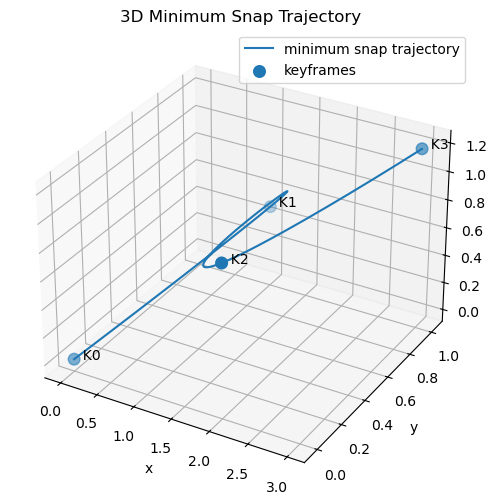

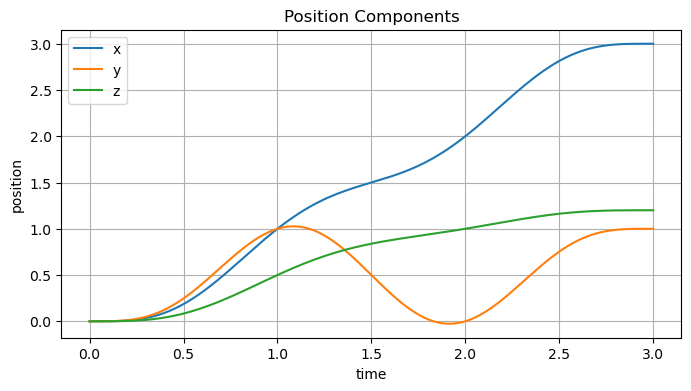

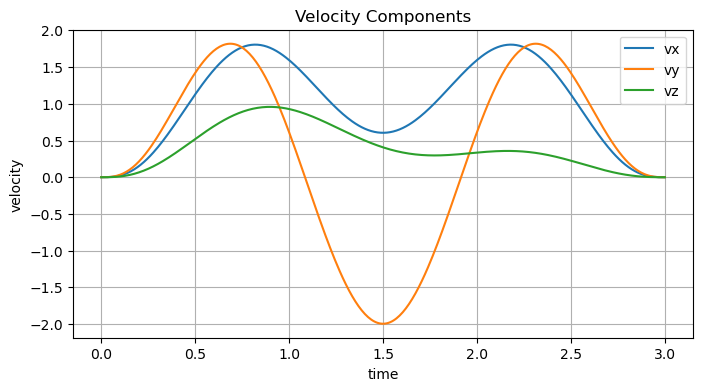

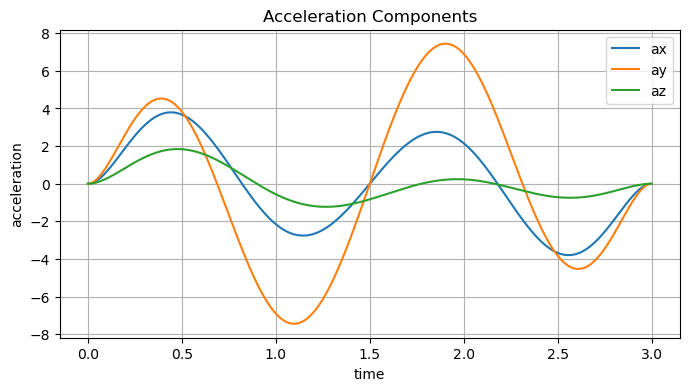

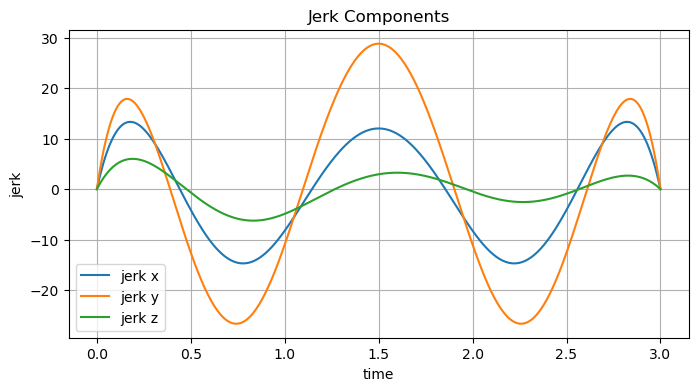

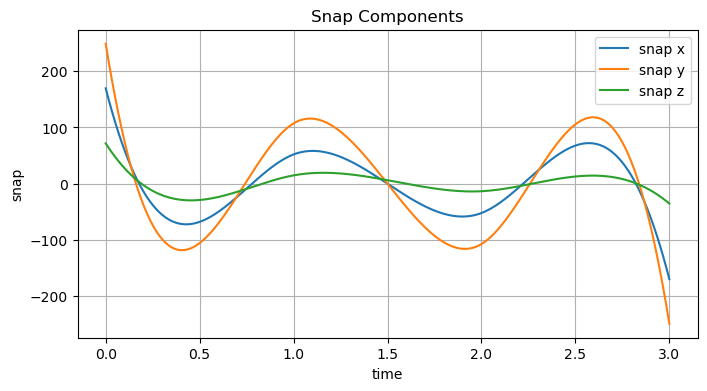

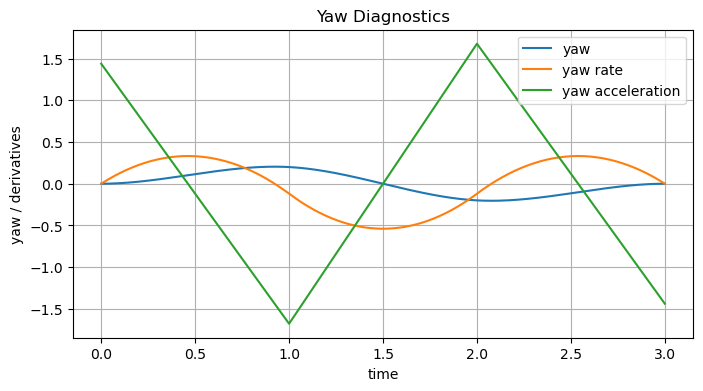

In [29]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_plot, y_plot, z_plot, label="minimum snap trajectory")
ax.scatter(keyframes[:, 0], keyframes[:, 1], keyframes[:, 2], s=70, label="keyframes")

for i, point in enumerate(keyframes):
    ax.text(point[0], point[1], point[2], f"  K{i}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Minimum Snap Trajectory")
ax.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, x_plot, label="x")
plt.plot(t_plot, y_plot, label="y")
plt.plot(t_plot, z_plot, label="z")
plt.xlabel("time")
plt.ylabel("position")
plt.title("Position Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, vx_plot, label="vx")
plt.plot(t_plot, vy_plot, label="vy")
plt.plot(t_plot, vz_plot, label="vz")
plt.xlabel("time")
plt.ylabel("velocity")
plt.title("Velocity Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, ax_plot, label="ax")
plt.plot(t_plot, ay_plot, label="ay")
plt.plot(t_plot, az_plot, label="az")
plt.xlabel("time")
plt.ylabel("acceleration")
plt.title("Acceleration Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, jx_plot, label="jerk x")
plt.plot(t_plot, jy_plot, label="jerk y")
plt.plot(t_plot, jz_plot, label="jerk z")
plt.xlabel("time")
plt.ylabel("jerk")
plt.title("Jerk Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, sx_plot, label="snap x")
plt.plot(t_plot, sy_plot, label="snap y")
plt.plot(t_plot, sz_plot, label="snap z")
plt.xlabel("time")
plt.ylabel("snap")
plt.title("Snap Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, yaw_plot, label="yaw")
plt.plot(t_plot, yaw_rate_plot, label="yaw rate")
plt.plot(t_plot, yaw_acc_plot, label="yaw acceleration")
plt.xlabel("time")
plt.ylabel("yaw / derivatives")
plt.title("Yaw Diagnostics")
plt.grid(True)
plt.legend()
plt.show()

### **6. 补充：为什么位置函数和偏航角函数可以用七阶多项式表示？**

1. 问题的本质：求“泛函”的极值

普通的求极值（比如求抛物线的最低点），是求一个变量（如 $x$），使得函数 $f(x)$ 最小。

但在这里，目标函数是：

$$J = \int_{0}^{T} (x^{(4)}(t))^2 dt$$

此时要找的不是一个具体的数字，而是一条曲线（一个函数 $x(t)$），使得这个积分的结果最小。这种“以函数为输入，输出一个实数”的映射，在数学上称为泛函（Functional）。

2. 解题工具：欧拉-拉格朗日方程

在变分法中，要想让一个积分泛函 $J = \int L(t, x, \dot{x}, \ddot{x}, \dots) dt$ 取得极值，它内部的函数 $x(t)$ 必须满足欧拉-拉格朗日方程（Euler-Lagrange Equation）。

对于包含了高阶导数的拉格朗日量 $L$，该方程的完整形态是：

$$\frac{\partial L}{\partial x} - \frac{d}{dt}\left(\frac{\partial L}{\partial x^{(1)}}\right) + \frac{d^2}{dt^2}\left(\frac{\partial L}{\partial x^{(2)}}\right) - \dots + (-1)^n \frac{d^n}{dt^n}\left(\frac{\partial L}{\partial x^{(n)}}\right) = 0$$

3. 代回的 Minimum Snap 问题

在这个问题中，拉格朗日量非常简单：$L = (x^{(4)})^2$。

把这个 $L$ 代入上面的方程，可以发现：

因为 $L$ 不含 $x, x^{(1)}, x^{(2)}, x^{(3)}$，所以前面的偏导数的值都为0；

唯一可能不为0的，只有最后一项（$n=4$）：

$$(-1)^4 \frac{d^4}{dt^4}\left(\frac{\partial L}{\partial x^{(4)}}\right) = 0$$

计算括号里的偏导数：对 $(x^{(4)})^2$ 求 $x^{(4)}$ 的偏导，结果是 $2 x^{(4)}$。

将结果代回：

$$\frac{d^4}{dt^4}\left( 2 x^{(4)} \right) = 0$$

约去常数2，再对 4 阶导数求 4 次时间导数，便得到了一个的微分方程：

$$x^{(8)}(t) = 0$$

4. 连续积分八次

欧拉-拉格朗日方程说明：任何能让 Snap 积分最小化的曲线，它的 8 阶导数必然恒等于 0。

那么，只需要对 0 连续进行 8 次积分：

- 积分 1 次：$x^{(7)}(t) = C_7$ （常数）
- 积分 2 次：$x^{(6)}(t) = C_7 t + C_6$
- 积分 3 次：$x^{(5)}(t) = \frac{1}{2} C_7 t^2 + C_6 t + C_5$
- ……
- 积分 8 次，最终得到：$$x(t) = c_7 t^7 + c_6 t^6 + c_5 t^5 + c_4 t^4 + c_3 t^3 + c_2 t^2 + c_1 t + c_0$$

因此，七阶多项式一定能准确地表示出 $r(t)$。